In [1]:
# Rotation of Hacat cells
import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import rotate, gaussian_filter
from scipy.stats import circmean
from scipy.interpolate import interpn
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
# from cellpose.io import imread
from cellpose import models, io
from skimage.measure import label, regionprops, regionprops_table
# from sklearn.neighbors import KDTree
from scipy.spatial.distance import pdist, squareform
# import statsmodels.api as sm

sys.path.append('../vasco_scripts')  # add the relative path to the folder
from defects import *  # import the module from the folder

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

sys.path.append('../cell_tracking_functions') 
from segmentation import * 

import btrack
from btrack import datasets
import napari
import matplotlib.pyplot as plt
import tifffile
from skimage.io import imread

class Tracklet: # A generic custom class example
    def __init__(self, track_id, x_coords, y_coords, frames):
        self.track_id = track_id
        self.x = x_coords
        self.y = y_coords
        self.t = frames
    
    def __repr__(self):
        return f'Tracklet(ID={self.track_id}, points={len(self.x)})'

In [2]:
def flows_from_raws(img1, img2, winsize=15, smooth_sigma=None, mask=None):
    # convert to 8-bit if necessary
    if img1.dtype != np.uint8:
        img1 = cv2.normalize(img1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if img2.dtype != np.uint8:
        img2 = cv2.normalize(img2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    if smooth_sigma is None:
        return cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 3, winsize=winsize,
                                            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    else:
        flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 3, winsize=winsize,
                                            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        flow_sm = np.empty_like(flow)
        flow_sm[..., 0] = gaussian_filter(flow[..., 0], sigma=smooth_sigma)
        flow_sm[..., 1] = gaussian_filter(flow[..., 1], sigma=smooth_sigma)

        if mask is not None:
            flow_sm[img1<mask, 0] = 1e-6
            flow_sm[img1<mask, 1] = 1e-6

        return flow_sm

def visualize_flow(flows, step=30):
    all_vecs = []
    # 2. Create (y, x) grid
    h, w = flows[0][::step, ::step].shape[:2]
    y, x = np.mgrid[0:h*step:step, 0:w*step:step]

    for t, flow in enumerate(flows):
        # 1. Downsample the grid
        sub_flow = flow[::step, ::step]
        
        # 3. Format coordinates: [t, y, x]
        # We add 't' so napari knows which frame the vector belongs to
        t_coords = np.full(y.size, t)
        pos = np.stack([t_coords, y.flatten(), x.flatten()], axis=1)
        
        # 4. Format displacements: [dt, dy, dx]
        # dt is 0 because the vector exists within a single frame
        dt = np.zeros(y.size)
        disp = np.stack([dt, sub_flow[..., 1].flatten(), sub_flow[..., 0].flatten()], axis=1)
        
        # 5. Stack into (N, 2, 3)
        frame_vecs = np.stack([pos, disp], axis=1)
        all_vecs.append(frame_vecs)   

    return np.concatenate(all_vecs, axis=0) 

def visualize_ori(oris, step=30):
    all_vecs = []
    # 2. Create (y, x) grid
    h, w = oris[0][::step, ::step].shape[:2]
    y, x = np.mgrid[0:h*step:step, 0:w*step:step]

    for t, ori in enumerate(oris):
        # 1. Downsample the grid
        sub_flow = ori[::step, ::step]
        
        # 3. Format coordinates: [t, y, x]
        # We add 't' so napari knows which frame the vector belongs to
        t_coords = np.full(y.size, t)
        pos = np.stack([t_coords, y.flatten(), x.flatten()], axis=1)
        
        # 4. Format displacements: [dt, dy, dx]
        # dt is 0 because the vector exists within a single frame
        dt = np.zeros(y.size)
        disp = np.stack([dt, -np.sin(sub_flow).flatten(), np.cos(sub_flow).flatten()], axis=1)
        
        # 5. Stack into (N, 2, 3)
        frame_vecs = np.stack([pos, disp], axis=1)
        all_vecs.append(frame_vecs)   

    return np.concatenate(all_vecs, axis=0) 


def visualize_ori_df(oris, step=30):
    all_frames = []
    
    # 1. Create (y, x) grid once (assuming all frames are same size)
    # Using oris[0].shape to ensure we cover the full image dimensions
    h, w = oris[0].shape
    y, x = np.mgrid[0:h:step, 0:w:step]

    for t, ori in enumerate(oris):
        sub = ori[::step, ::step]
        
        # 2. Build DataFrame for this frame
        # 'sub' is used for dy, dx, and the 'ori' property
        df = pd.DataFrame({
            't': t,
            'y': y.flatten(),
            'x': x.flatten(),
            'dt': 0,
            'dy': -np.sin(sub).flatten() * step, # Scaled for visibility
            'dx': np.cos(sub).flatten() * step,
            'orientation': sub.flatten()
        })
        all_frames.append(df)

    # 3. Consolidate into one DataFrame
    full_df = pd.concat(all_frames, ignore_index=True)

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    # disp = full_df[['dt', 'dy', 'dx']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df

def visualize_defects(df_list, ang='ang1'):
    all_frames = []

    for t, p in enumerate(df_list):
        df = pd.DataFrame({
            't': t,
            'y': p['y'].values,
            'x': p['x'].values,
            'dt': 0,
            'dy': np.sin(p[ang]), # Scaled for visibility
            'dx': np.cos(p[ang]),
        })

        all_frames.append(df)

    # 3. Consolidate into one DataFrame
    full_df = pd.concat(all_frames, ignore_index=True)

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df


def visualize_defects_from_table(df_all, ang='ang1'):
    df_all['dt'] = 0
    df_all['dy'] = np.sin(df_all[ang])
    df_all['dx'] = np.cos(df_all[ang])
    full_df = df_all.copy()

    # 4. Extract the (N, 2, 3) NumPy array required by napari
    # Format: [ [t, y, x], [dt, dy, dx] ]
    pos = full_df[['t', 'y', 'x']].values
    disp = full_df[['dt', 'dy', 'dx']].values
    vec_data = np.stack([pos, disp], axis=1)

    return vec_data, full_df


def flow_to_tracks(flow_series, step=40, iterations=None):
    """
    Converts a sequence of dense flow fields into trajectories.
    
    :param flow_series: List or array of shape (T, H, W, 2) where [..., 0] is dx and [..., 1] is dy
    :param step: N (integer). Seeds a track every N pixels.
    :param iterations: Number of frames to process.
    :return: Array of tracks with shape (Num_Tracks, T, 2)
    """
    T, H, W, _ = flow_series.shape
    iterations = iterations if iterations else T
    
    # 1. Initialize Seed Points (x, y) every N pixels
    yy, xx = np.mgrid[step//2:H:step, step//2:W:step]
    # ensure floating point positions to allow in-place addition of float displacements
    current_points = np.vstack([xx.ravel(), yy.ravel()]).T.astype(np.float64)
    
    # Initialize track storage: (Number of points, Time, 2) as float
    tracks = np.zeros((current_points.shape[0], iterations + 1, 2), dtype=np.float64)
    tracks[:, 0, :] = current_points
    
    # Define grid coordinates for interpolation
    grid_y = np.arange(H)
    grid_x = np.arange(W)

    # 2. Integrate Velocity Vectors
    for t in range(iterations):
        # Extract flow for the current frame
        flow_frame = flow_series[t]
        
        # Interpolate dx and dy at the current floating-point positions
        # Using 'linear' to handle points between pixels
        dx = interpn((grid_y, grid_x), flow_frame[..., 0], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        dy = interpn((grid_y, grid_x), flow_frame[..., 1], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        
        # 3. Update Positions: x_new = x + dx, y_new = y + dy
        current_points[:, 0] += dx
        current_points[:, 1] += dy
        
        # Store the updated position
        tracks[:, t + 1, :] = current_points

    
    
    n_tracks, n_timesteps, _ = tracks.shape
    track_ids = np.repeat(np.arange(n_tracks), n_timesteps)
    times = np.tile(np.arange(n_timesteps), n_tracks)
    coords = tracks.reshape(n_tracks * n_timesteps, 2)    
    
    
    return pd.DataFrame({
                        'track_id': track_ids,
                        't': times,
                        'x': coords[:, 0],
                        'y': coords[:, 1],
                        })

In [3]:
# FUCCI
def read_image(path, rotate_angle=None):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.uint8)
    # img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    if rotate_angle is not None:
        img_rot = rotate(img, rotate_angle, reshape=False)
        return img_rot
    return img

path = r"E:\HT1080\HT1080 FUCCI Pattern_6Well_5min_5x\_7\Pos19"

first_img = 160
last_img = 220
image_list = natsorted(glob.glob(path + r"\img_channel000_*.tif"), key=lambda y: y.lower())[first_img:last_img]
green_list = natsorted(glob.glob(path + r"\img_channel001_*.tif"), key=lambda y: y.lower())[first_img:last_img]
red_list = natsorted(glob.glob(path + r"\img_channel002_*.tif"), key=lambda y: y.lower())[first_img:last_img]

rotate_angle = -11.3
raws = np.array([read_image(im, rotate_angle=rotate_angle) for im in image_list])
greens = np.array([read_image(im, rotate_angle=rotate_angle) for im in green_list])
reds = np.array([read_image(im, rotate_angle=rotate_angle) for im in red_list])

In [13]:
viewer = napari.Viewer()

viewer.add_image(greens, name='Greens', colormap='green', opacity=1, contrast_limits=(.9, 8))
viewer.add_image(reds, name='Reds', colormap='red', opacity=0.4, contrast_limits=(2, 4))
viewer.add_image(raws, name='Raws', colormap='gray', opacity=0.4, contrast_limits=(0, 20))

<Image layer 'Raws' at 0x1bbe14d3580>

In [12]:
# Division events masked by the raw images, to be visualized in napari

# path = r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\w700\s205"
path = r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\w400\s88_3"
image_list = natsorted(glob.glob(path + r"\Raw\*.tif"), key=lambda y: y.lower())
mask_list = natsorted(glob.glob(path + r"\Mask2\*.png"), key=lambda y: y.lower())
masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in mask_list]) 

raws = np.array([255-cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in image_list])

df_path = path + r"\First_appearance_events.csv"
divisions = pd.read_csv(df_path).dropna()


In [13]:
viewer = napari.Viewer()
viewer.add_image(raws, name='Raws', colormap='gray')
viewer.add_labels(masks, name="Segmentation", opacity=0.2) 

# Create the range of timestamps for each row
df_expanded = divisions[['first_frame', 'first_y', 'first_x']][
    (divisions['first_frame']>0)&(divisions['first_frame']<raws.shape[0]-5)
    ].copy()
df_expanded['first_frame'] = df_expanded['first_frame'].apply(lambda t: list(range(t, t + 5)))

# Explode the list into individual rows
df_expanded = df_expanded.explode('first_frame').reset_index(drop=True)

# Add to napari
viewer.add_points(
    df_expanded[['first_frame', 'first_y', 'first_x']].values,
    name='Divisions Expanded',
    size=30,
    face_color="#ff4747ff", 
    opacity=0.3,
)

viewer.add_points(
    divisions[['first_frame', 'first_y', 'first_x']][divisions['first_frame']>0].values,
    name='Divisions',
    size=50,
    face_color="#ff4747ff", 
    opacity=0.3,
)

<Points layer 'Divisions' at 0x1e870136a40>

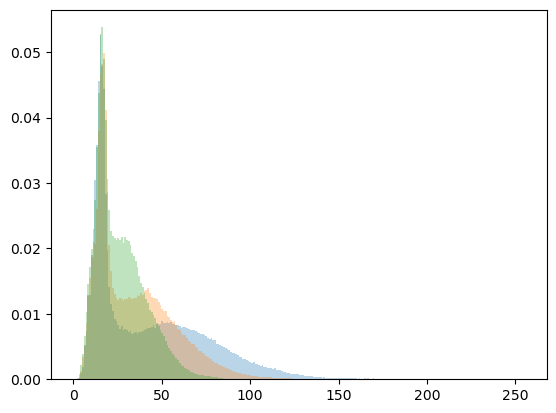

In [71]:
for r in raws[:3]:
    # convert to 8-bit if necessary
    if r.dtype != np.uint8:
        r = cv2.normalize(r, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    plt.hist(r.ravel(), bins=256, range=(0, 255), density=True, alpha=0.3)

In [17]:
# Explain

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\Cellmask2_40X\_16_5min\Default"
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\Cellmask3_40X\_3\Pos8"


# 4D
# image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
# raws = np.array([clahe.apply(cv2.imread(im, cv2.COLOR_RGB2GRAY) )for im in image_list])

# 3D
image_list = natsorted(glob.glob(path + r"\*_z003.tif"), key=lambda y: y.lower())
raws = np.array([clahe.apply(cv2.imread(im, cv2.COLOR_RGB2GRAY) )for im in image_list])
# flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=35, mask=60) for r1, r2 in zip(raws[:-1], raws[1:]))


In [45]:
# using max projection along z-axis for 3D time-lapse data
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\Cellmask3_40X\_3\Pos3"

raws = []
for t in range(10):
    image_list = natsorted(glob.glob(path + r"\*_time0000000"+f"{t:02d}"+r"_z*.tif"), key=lambda y: y.lower())
    raw = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in image_list])
    raws.append(clahe.apply(raw.max(axis=0)))  # Take max projection along z-axis and apply CLAHE

In [46]:
flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=30, mask=10) for r1, r2 in zip(raws[:-1], raws[1:]))
ori_sigma = 5
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=ori_sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

In [54]:
viewer = napari.Viewer()
# 4D
# viewer.add_image(np.array(raws).reshape(10,8, raws.shape[-2], raws.shape[-1]), name='Raws', colormap='gray')

# flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=11) for r1, r2 in zip(raws[:-1], raws[1:]))

# 3D
viewer.add_image(np.array(raws), name='Raws', colormap='gray')
viewer.add_vectors(
    visualize_flow(flows, step=11), 
    edge_width=2, length=4, 
    edge_color="#ca1818ff", vector_style='triangle',
    name='Flow Field'
)

viewer.add_vectors(
    visualize_ori(oris, step=11), 
    edge_width=1., length=10, 
    edge_color="#00c528ab", vector_style='line', opacity=0.6,
    name='Orientation Field'
)

<Vectors layer 'Orientation Field' at 0x2848eabb7f0>

Save data:

In [49]:
import h5py

def flow_save(flows, save_path):
    os.makedirs(save_path, exist_ok=True)   

    for i,flow in enumerate(flows):
        with h5py.File(save_path +"/flow_"+ str(i), 'w') as f:
                    f.create_dataset('flow', data=flow.astype(np.float16))


save_path  = path + "/Flow"
os.makedirs(save_path, exist_ok=True)
flow_save(flows, save_path)            

In [53]:
def ori_save(oris, save_path):
    os.makedirs(save_path, exist_ok=True)   

    for i,ori in enumerate(oris):
        cv2.imwrite(save_path +"/ori_"+ str(i)+".tif", ori)


save_path  = path + "/Nematic"
os.makedirs(save_path, exist_ok=True)
ori_save(oris, save_path)  

In [55]:
def raw_save(raws, save_path):
    os.makedirs(save_path, exist_ok=True)   

    for i,raw in enumerate(raws):
        cv2.imwrite(save_path +"/raw_"+ str(i)+".tif", raw)


save_path  = path + "/Raw"
os.makedirs(save_path, exist_ok=True)
raw_save(raws, save_path) 


In [72]:
# Load and view saved data

path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\Cellmask3_40X\_3\Pos3"

image_list = natsorted(glob.glob(os.path.join(os.path.join(path, 'Raw'), "*")), key=lambda y: y.lower())
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in image_list])

image_list = natsorted(glob.glob(os.path.join(os.path.join(path, 'Mask_d80_fl05_cprob0'), "*")), key=lambda y: y.lower())
masks = np.array([cv2.imread(im, cv2.IMREAD_UNCHANGED) for im in image_list])

image_list = natsorted(glob.glob(os.path.join(os.path.join(path, 'Nematic'), "*")), key=lambda y: y.lower())
oris = np.array([cv2.imread(im, cv2.IMREAD_UNCHANGED) for im in image_list])

image_list = natsorted(glob.glob(os.path.join(os.path.join(path, 'Flow'), "*")), key=lambda y: y.lower())
flows = []
for im in image_list:
    with h5py.File(im, 'r') as f: 
        # Get the dataset (matrix) from the file
        flow = f['flow'][:].astype(np.float32)  
        flows.append(flow)


viewer = napari.Viewer()
viewer.add_image(raws, name='Raws', colormap='gray')
viewer.add_image(masks, name='Masks', colormap='gray')
viewer.add_vectors(
    visualize_ori(oris, step=11), 
    edge_width=1., length=10, 
    edge_color="#00c528ab", vector_style='line', opacity=0.6,
    name='Orientation Field'
)
viewer.add_vectors(
    visualize_flow(flows, step=11), 
    edge_width=2, length=4, 
    edge_color="#ca1818ff", vector_style='triangle',
    name='Flow Field'
)
      

<Vectors layer 'Flow Field' at 0x284bc8c4b50>

In [48]:
has

NameError: name 'has' is not defined

In [ ]:
# Cells
path = r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)"
mask_list = natsorted(glob.glob(path + r"\Mask\*.png"), key=lambda y: y.lower())
image_list = natsorted(glob.glob(path + r"\Raw\*.tif"), key=lambda y: y.lower())
# masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[800:1600,800:1600] for im in mask_list[380:430]]) #[300:350][100:600,100:600]
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[800:1300,800:1300] for im in image_list[220:320]])  

# masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in mask_list[300:350]]) #[100:600,100:600]
# raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in image_list[300:350]])  
winsize = 15
flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=winsize) for r1, r2 in zip(raws[:-1], raws[1:]))
vorticity = np.array([gaussian_filter(curl_npgrad(f), sigma=30) for f in flows])

ori_sigma = 25
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=ori_sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

orders = np.array([order_parameter(ori, kernel_size=31) for ori in oris])

In [ ]:
# Bacteria
path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6"
# path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\deep"
image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())

raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[100:800,1000:-100] for im in image_list[:100]])  

# masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in mask_list[300:350]]) #[100:600,100:600]
# raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in image_list[300:350]])  
winsize = 15
flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=winsize) for r1, r2 in zip(raws[:-1], raws[1:]))
# shear = np.array([gaussian_filter(shear_rate_2d(f), sigma=15) for f in flows])
# vorticity = np.array([gaussian_filter(curl_npgrad(f), sigma=15) for f in flows])


ori_sigma = 11
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=ori_sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

orders = np.array([order_parameter(ori, kernel_size=31) for ori in oris])

In [ ]:
plus_data, plus_features = visualize_defects(plus[:-1], ang='ang1')
pdefect = viewer.add_vectors(
    plus_data,
    features=plus_features,
    edge_width=9, vector_style='triangle',
    length=50, # Since we scaled dy/dx by step in the function
    name='Plus',
    opacity=0.6,
)
pdefect.edge_color_mode = 'direct'
pdefect.edge_color ="#ffffffff"  # Updates all vectors to this color

for i in range(3):
    plus_data, plus_features = visualize_defects(min[:-1], ang='ang'+str(i+1))
    pdefect = viewer.add_vectors(
        plus_data,
        features=plus_features,
        edge_width=9, vector_style='triangle',
        length=30, # Since we scaled dy/dx by step in the function
        name='Minus ang'+str(i+1),
        opacity=0.6, edge_color="#c129c6ff"
    ) 
    pdefect.edge_color_mode = 'direct'  
    edge_color="#c129c6ff"

In [ ]:
flow_step = 17# winsize
ori_step = 15 #ori_sigma

# 6. Launch Viewer
viewer = napari.Viewer()
viewer.add_image(raws[:len(flows)], name='Raws', colormap='gray')

# viewer.add_image(
#     # shear[:len(flows)],
#     # name="shear",
#     vorticity[:len(flows)],
#     name="Vorticity",
#     opacity=0.6,
#     colormap='I Bordeaux'
# )  

# viewer.add_image(
#     orders[:len(flows)],
#     name="Oreder Parameter",
#     opacity=0.6,
#     colormap='ice'
# )  

vec_data, df_features = visualize_ori_df(oris[:-1], step=ori_step)
# Add the vectors layer
vectors_layer = viewer.add_vectors(
    vec_data,
    features=df_features,
    edge_width=2, vector_style='line',
    length=1, # Since we scaled dy/dx by step in the function
    name='Orientations',
    edge_color='orientation',  # Map color to the 'orientation' column in DF
    # edge_colormap='hsv'        # Circular colormap perfect for angles
)

# viewer.add_vectors(
#     visualize_ori(oris[:-1], step=ori_step), 
#     edge_width=1., length=20, 
#     edge_color="#00c528ab", vector_style='line', opacity=0.6,
#     name='Orientation Field'
# )


viewer.add_vectors(
    visualize_flow(flows, step=flow_step), 
    edge_width=1.5, length=5, 
    edge_color="#ca1818ff", vector_style='arrow',
    name='Flow Field'
)

plus_data, plus_features = visualize_defects(plus[:-1], ang='ang1')
pdefect = viewer.add_vectors(
    plus_data,
    features=plus_features,
    edge_width=9, vector_style='triangle',
    length=50, # Since we scaled dy/dx by step in the function
    name='Plus',
    opacity=0.6,
)
pdefect.edge_color_mode = 'direct'
pdefect.edge_color ="#ffffffff"  # Updates all vectors to this color

for i in range(3):
    plus_data, plus_features = visualize_defects(min[:-1], ang='ang'+str(i+1))
    pdefect = viewer.add_vectors(
        plus_data,
        features=plus_features,
        edge_width=9, vector_style='triangle',
        length=30, # Since we scaled dy/dx by step in the function
        name='Minus ang'+str(i+1),
        opacity=0.6, edge_color="#c129c6ff"
    ) 
    pdefect.edge_color_mode = 'direct'  
    edge_color="#c129c6ff"

# viewer.add_image(
#     masks[:len(flows)],
#     name="Segmentation",
#     opacity=0.2,
# ) 

# df_trajectories = flow_to_tracks(np.array(flows)[:-1], step=15)
# viewer.add_tracks(
#     df_trajectories[['track_id', 't', 'y', 'x']].to_numpy(),
#     properties=df_trajectories,
#     blending='translucent',
#     visible=True,
# )

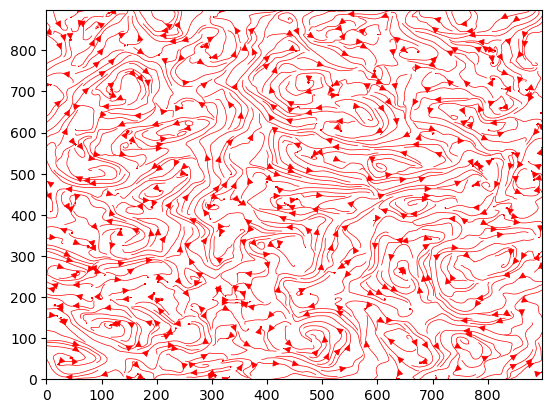

In [ ]:
y, x = np.mgrid[0:flows[0].shape[0], 0:flows[0].shape[0]]
plt.streamplot(
    x,y,
    flows[0][..., 0], flows[0][..., 1], 
    density=4.1, color='r', linewidth=0.5)

In [ ]:
sst

In [ ]:
# Bacteria
path = r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\ISF defects new\6"
image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[:,:] for im in image_list[:100]])

# exp_num = 4
# path = r"C:\Users\victo\OneDrive - BGU\HBEC\s" + str(exp_num) + "(120-919)\Raw"
# image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
# raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[:,:] for im in image_list[160:500]])  


minimal_track = 1
plus_minus_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_bacteria6_all.csv").dropna(subset=["min_id","creation"])
# plus_minus_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s" + str(exp_num) + ".csv").dropna(subset=["min_id","creation"])

plus_minus_df = plus_minus_df.groupby('plus_id').filter(lambda x : len(x)>minimal_track).copy()

# df_plus = pd.DataFrame()
# df_minus = pd.DataFrame()
# df_plus[['t','x','y','ang1','fuse_up']] = plus_minus_df[['FRAME','xp','yp','angp1','fuse_up']][plus_minus_df.fusion].copy()
# df_minus[['t','x', 'y', 'ang1','ang2','ang3','fuse_up']] = plus_minus_df[['FRAME','xm','ym','angm1','angm2','angm3','fuse_up']][plus_minus_df.fusion].copy()

# print("Number of plus tracks: %s" %df_plus.shape[0])
# print("Number of minus tracks: %s" %df_minus.shape[0])

In [ ]:
sigma = 11 #21 #11

ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

In [ ]:
# t = pd.DataFrame()
# t = plus_minus_df[ (plus_minus_df['fusion'])&(plus_minus_df['FRAME']<100)].copy()
# # the track data from the tracker
# viewer.add_tracks(
#     t[['plus_id','FRAME','yp','xp']].to_numpy(),
#     properties = t,
#     name="plus_TrackPy_filt",
#     blending="translucent",
#     visible=True,
# )
# viewer.add_tracks(
#     t[['min_id','FRAME','ym','xm']].to_numpy(),
#     properties = t,
#     name="minus_TrackPy_filt",
#     blending="translucent",
#     visible=True,
# )

<Tracks layer 'minus_TrackPy_filt [1]' at 0x1c185257340>

In [ ]:
process_type = ['fusion', 'creation']
pcolor = ["#3d9bffff", "#ff4747ff"]
mcolor = ["#3d9bffff", "#ff4747ff"]

viewer = napari.Viewer()

for pcol,mcol,ptype in zip(pcolor, mcolor, process_type):
    df_plus = pd.DataFrame()
    df_minus = pd.DataFrame()

    df_plus[['t','x','y','ang1','fuse_up']] = plus_minus_df[['FRAME','xp','yp','angp1','fuse_up']][plus_minus_df[ptype]].copy()
    df_minus[['t','x', 'y', 'ang1','ang2','ang3','fuse_up']] = plus_minus_df[['FRAME','xm','ym','angm1','angm2','angm3','fuse_up']][plus_minus_df[ptype]].copy()

    df_plus_ = df_plus[df_plus['t']<len(raws)].copy()
    df_minus_ = df_minus[df_minus['t']<len(raws)].copy()

    plus_data, plus_features = visualize_defects_from_table(df_plus_, ang='ang1')
    pdefect = viewer.add_vectors(
        plus_data, #features=plus_features,
        edge_width=15, length=int(3*sigma),
        edge_color=pcol, vector_style='triangle',
        name='Plus',
    )

    for i in range(3):
        plus_data, plus_features = visualize_defects_from_table(df_minus_, ang='ang'+str(i+1))
        pdefect = viewer.add_vectors(
        plus_data, # features=plus_features,
        edge_width=15, length=int(3*sigma),
        edge_color=mcol, vector_style='triangle', opacity=1,
        name='Minus ang'+str(i+1),
        )
    
    break

plus_data, plus_features = visualize_defects(plus, ang='ang1')
pdefect = viewer.add_vectors(
        plus_data, #features=plus_features,
        edge_width=10, length=int(2*sigma),
        edge_color='w', vector_style='triangle', opacity=0.3,
        name='Plus_all',
)
for i in range(3):
    plus_data, plus_features = visualize_defects(min, ang='ang'+str(i+1))
    pdefect = viewer.add_vectors(
        plus_data, # features=plus_features,
        edge_width=10, length=int(2*sigma),
        edge_color='w', vector_style='triangle', opacity=0.3,
        name='Minus ang'+str(i+1),
    ) 

# viewer.add_vectors(
#     visualize_ori(oris, step=int(1.2*sigma)), 
#     edge_width=2., length=20, 
#     edge_color="#fffb19ff", vector_style='line', opacity=1,
#     name='Orientation Field'
# )    

viewer.add_image(raws, name='Raws', colormap='gray', opacity=0.3)

<Image layer 'Raws' at 0x1c185192530>

In [ ]:
viewer.add_vectors(
    visualize_ori(oris, step=int(1.2*sigma)), 
    edge_width=2., length=20, 
    edge_color="#fffb19ff", vector_style='line', opacity=1,
    name='Orientation Field'
)   

<Vectors layer 'Orientation Field' at 0x2ad88d4a9e0>

In [ ]:
stt

In [ ]:
len(image_list)

301

In [ ]:
# Cells
path = r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\w400\s88_3"

experiment = "s11" 
path = r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment

image_list = natsorted(glob.glob(path + r"*.tif"), key=lambda y: y.lower())[100:220]
raws = np.array([255-cv2.imread(im, cv2.IMREAD_GRAYSCALE)[:1000,:1000] for im in image_list])  
# raws = np.array([255-rotate(cv2.imread(im, cv2.COLOR_RGB2GRAY),90) for im in image_list[120:220]])

# mask_list = natsorted(glob.glob(path + r"\Mask2\*.png"), key=lambda y: y.lower())
# masks = np.array([rotate(cv2.imread(im, cv2.COLOR_RGB2GRAY),90) for im in mask_list[:50]]) 

In [ ]:
viewer = napari.Viewer()
viewer.add_image(raws, name='Raws', colormap='gray')
# viewer.add_image(masks, name="Segmentation", opacity=0.2)

<Image layer 'Raws' at 0x122d2417310>

In [ ]:
winsize = 15
flows = Parallel(n_jobs=-1)(delayed(flows_from_raws)(r1, r2, winsize=winsize) for r1, r2 in zip(raws[:-1], raws[1:]))
viewer.add_vectors(
    visualize_flow(flows, step=int(1.5*winsize)), 
    edge_width=2.5, length=5, 
    edge_color="#ca1818ff", vector_style='arrow',
    name='Flow Field'
)

<Vectors layer 'Flow Field' at 0x122ded9f5e0>

In [ ]:
ori_sigma = 25
ori_plus_min = Parallel(n_jobs=-1)(delayed(analyze_defects)(r, sigma=ori_sigma) for r in raws)
oris, plus, min = [], [], []
for q in ori_plus_min:
    oris.append(q[0])
    plus.append(q[1])
    min.append(q[2]) 

orders = np.array([order_parameter(ori, kernel_size=31) for ori in oris])

In [ ]:
viewer.add_image(
    orders[:len(flows)],
    name="Oreder Parameter",
    opacity=0.6,
    colormap='ice'
) 

<Image layer 'Oreder Parameter' at 0x122c9519b10>

In [ ]:
st

In [ ]:
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\c3_6well_5min_10x\Pos4"
# path = r"C:\Users\victo\OneDrive - BGU\DATA\HBEC\s2"
mask_list = natsorted(glob.glob(path + r"\Mask\*.tif"), key=lambda y: y.lower())
masks = np.array([cv2.imread(mask, cv2.COLOR_RGB2GRAY)[:, :] for mask in mask_list])   

In [ ]:
CONFIG_FILE = datasets.cell_config()
SEGMENTATION_FILE = datasets.example_segmentation_file()
OBJECTS_FILE = datasets.example_track_objects_file()
FEATURES = ["area", "major_axis_length", "minor_axis_length", "orientation", "solidity"]

# segmentation = tifffile.imread(SEGMENTATION_FILE)[:50]
# segmentation = imread(SEGMENTATION_FILE)[:50]

objects = btrack.utils.segmentation_to_objects(
    masks,
    properties=tuple(FEATURES),
    # num_workers=4,  # parallelise this
)

[INFO][2026/01/27 02:31:20 PM] Localizing objects from segmentation...
progress: 100%|██████████| 50/50 [00:12<00:00,  4.15it/s]
[INFO][2026/01/27 02:31:32 PM] Objects are of type: <class 'dict'>
[INFO][2026/01/27 02:31:32 PM] ...Found 8602 objects in 50 frames.


In [ ]:
# import json

# with open(datasets.cell_config(), 'r') as file:
#     data = json.load(file)
# print(data)   

In [ ]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:
    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 30
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume = ((0, masks.shape[-1]), (0, masks.shape[-2]))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()

    # store the tracks
    tracks = tracker.tracks

    # store the configuration
    cfg = tracker.configuration

    # export the track data
    # tracker.export("tracks.h5", obj_type="obj_type_1")

[INFO][2026/01/27 02:31:32 PM] Loaded btrack: C:\Users\victo\miniconda3\envs\cellpose41\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/01/27 02:31:32 PM] Starting BayesianTracker session
[INFO][2026/01/27 02:31:32 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\cell_config.json


[INFO][2026/01/27 02:31:32 PM] Objects are of type: <class 'list'>
[INFO][2026/01/27 02:31:32 PM] Starting tracking... 
[INFO][2026/01/27 02:31:32 PM] Update using: ['VISUAL', 'MOTION']
[INFO][2026/01/27 02:31:32 PM] Tracking objects in frames 0 to 50 (of 50)...
[INFO][2026/01/27 02:31:33 PM]  - Timing (Bayesian updates: 4.00ms, Linking: 0.00ms)
[INFO][2026/01/27 02:31:33 PM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2026/01/27 02:31:33 PM] SUCCESS.
[INFO][2026/01/27 02:31:33 PM]  - Found 516 tracks in 50 frames (in 0.0s)
[INFO][2026/01/27 02:31:33 PM]  - Inserted 393 dummy objects to fill tracking gaps
[INFO][2026/01/27 02:31:33 PM] Loading hypothesis model: cell_hypothesis
[INFO][2026/01/27 02:31:33 PM] Calculating hypotheses (relax: True)...
[INFO][2026/01/27 02:31:33 PM] Setting up constraints matrix for global optimisation...
[INFO][2026/01/27 02:31:33 PM] Optimizing...
[INFO][2026/01/27 02:31:33 PM] Optimization complete. (Solution: optimal)
[INFO][2026/01/27 02:31:3

In [ ]:
# # path = r"C:\Users\victo\OneDrive - BGU\BEER\Gil\tracks"
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\c3_6well_5min_10x\Pos4"
mask_list = natsorted(glob.glob(path + r"\Mask\*.tif"), key=lambda y: y.lower())
image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in mask_list]) #[300:1000, 500:1200]
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)for im in image_list[:len(masks)]]) 

viewer = napari.Viewer()
viewer.add_image(
    # segmentation,
    masks,
    name="Segmentation",
    opacity=0.2,
)

viewer.add_image(
    # segmentation,
    raws,
    name="Raw",
    opacity=0.2,
)

# # the track data from the tracker
# viewer.add_tracks(
#     data,
#     properties=properties,
#     graph=graph,
#     name="Tracks",
#     blending="translucent",
#     visible=True,
# )

<Image layer 'Raw' at 0x21d5e6b0fa0>

In [ ]:
def uv_list(img1, img2, sigma=15):
    flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
        winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
    return gaussian_filter(flow[..., 0], sigma=sigma), gaussian_filter(flow[..., 1], sigma=sigma)

vel_list = Parallel(n_jobs=4)(delayed(uv_list)(img1,img2,sigma=30) for (img1,img2) in zip(raw_shifted[:-1],raw_shifted[1:]))
u = [vel[0] for vel in vel_list]
v = [vel[1] for vel in vel_list]

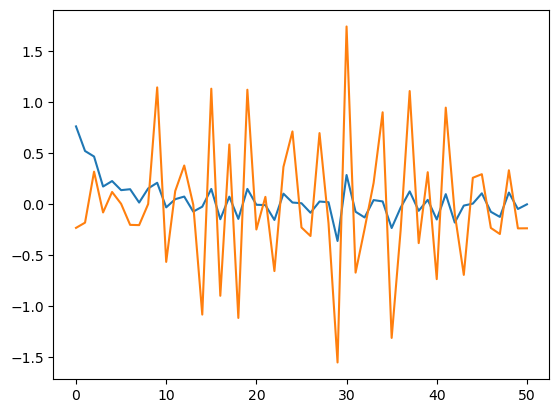

In [ ]:
%matplotlib inline
plt.plot([np.median(vel[0]) for vel in vel_list])
plt.plot([np.median(vel[1]) for vel in vel_list])

In [ ]:
u_shift = [np.median(vel[0]) for vel in vel_list]
v_shift = [np.median(vel[0]) for vel in vel_list]
raw_shifted = []
raw_shifted.append(raws[0])
rows, cols = raws[0].shape[:2]
for raw, dx,dy in zip(raws[1:], u_shift, v_shift):
    # Shift 100 pixels right, 50 pixels down
    M = np.float32([[1, 0, dx], [0, 1, -dy]])
    raw_shifted.append(cv2.warpAffine(raw, M, (cols, rows)))

In [ ]:
viewer.add_image(
    # segmentation,
    np.array(raw_shifted),
    name="Raw_shifted",
    opacity=0.2,
)

<Image layer 'Raw_shifted' at 0x17f59d00640>

In [ ]:
# Extract tracks from Viewer
tracks_data = viewer.layers['Segmentation_btrack'].data
df = pd.DataFrame(tracks_data, columns=['track_id', 't', 'y', 'x'])

# Group by track ID and calculate displacement
track_stats = df.groupby('track_id').agg({
    'x': ['first', 'last'],
    'y': ['first', 'last'],
    't': 'count'
}).reset_index()

track_stats.columns = ['track_id', 'x_start', 'x_end', 'y_start', 'y_end', 'num_points']

# Calculate total displacement
track_stats['displacement'] = np.sqrt(
    (track_stats['x_end'] - track_stats['x_start'])**2 + 
    (track_stats['y_end'] - track_stats['y_start'])**2
)

# Filter for long moving tracks (adjust threshold as needed)
min_displacement = 50
long_tracks = track_stats[track_stats['displacement'] > min_displacement]['track_id'].values

df_long_tracks = df[df['track_id'].isin(long_tracks)].copy()

viewer.add_tracks(
    df_long_tracks[['track_id', 't', 'y', 'x']].to_numpy(),
)

[DEBUG][2026/01/27 02:42:43 PM] Not selecting new layer Tracks as input for the segmentation widget as Tracks is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.
[DEBUG][2026/01/27 02:42:43 PM] Not selecting new layer Tracks as input for the segmentation widget as Tracks is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.


<Tracks layer 'Tracks' at 0x213cbe8b280>

In [ ]:
df_list = []
for frame, mask in enumerate(masks):
    # Calculate neighbors
    neighbors = calculate_neighbors(mask)
    

    # Create DataFrame
    df_neighbors = create_dataframe(neighbors)
    df_neighbors["frame"] = frame
    df_list.append(df_neighbors)
    # break

features = pd.concat(df_list, ignore_index=True)

In [ ]:
search_range = 15 #15
# t = tp.link_df(features[features["Area"]>250], search_range, memory=2)
t = tp.link_df(features, search_range, memory=2)
t_filt = t.groupby('particle').filter(lambda x: len(x)>5).copy()

Frame 49: 909 trajectories present.


In [ ]:
t['isolated'] = ~t.groupby('particle')['Neighbors Num'].transform(lambda x: x.gt(0).any())

In [ ]:
t[t['particle']==31]

,Cell,x,y,Area,Perimeter,Neighbors Num,Neighbors,frame,particle,isolated
127,128,363.370750,906.301475,1559.0,159.497475,0,[],0,31,False
298,127,365.836196,903.871166,1630.0,160.811183,0,[],1,31,False
472,130,364.972332,904.648221,1771.0,193.681241,0,[],2,31,False
646,127,364.686720,904.236663,1762.0,194.610173,0,[],3,31,False
819,128,366.075483,895.071740,1603.0,163.195959,0,[],4,31,False
1001,128,367.443997,886.145044,1241.0,129.882251,0,[],5,31,False
1182,135,367.208364,883.547322,1363.0,137.053824,0,[],6,31,False
1362,134,367.893847,879.774848,1479.0,143.296465,0,[],7,31,False
1545,133,369.217213,873.142623,1220.0,130.468037,0,[],8,31,False
1728,136,367.635370,870.434727,1555.0,146.610173,0,[],9,31,False


In [ ]:
t_filt = t[
    (t['Neighbors Num']==0)&
    (t['x']>50)&(t['x']<t['x'].max()-50)&(t['y']>50)&(t['y']<t['y'].max()-50)
    ].copy()

In [ ]:
%matplotlib qt
selection = t[["frame","Cell"]][
    t['particle']==129
    # (t['particle']==31) | (t['particle']==288)
]
colors = plt.cm.jet(np.linspace(0, 1, len(masks)))

raw_masked = np.zeros_like(masks)

for i,sel in enumerate(selection.itertuples()):
    
    # print(sel.frame, sel.Cell)
    mask = masks[sel.frame]==sel.Cell
    raw_masked[sel.frame] = raws[sel.frame]*mask

    if i%5:        
        # plt.imshow(mask, cmap='gray', alpha=0.1)
        plt.imshow(raw_masked[-1], cmap='gray', alpha=0.6)


    
        contours = cv2.findContours((mask).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        pvc, pvr = np.concatenate(contours[-2], axis=0).squeeze().T


    #     # ax1.contour(outlines, colors=[c], alpha=0.3, linewidths=3)
        # plt.plot(pvc, pvr, color=colors[i], linewidth=3, alpha=0.3)


In [ ]:
viewer.add_image(
    # segmentation,
    raw_masked,
    name="I129",
    opacity=0.2,
)

<Image layer 'I129' at 0x17f5fb315d0>

In [ ]:
# # the track data from the tracker
# viewer.add_tracks(
#     t[['particle','frame','y','x']].to_numpy(),
#     properties = t,
#     # graph=graph,
#     name="TrackPy",
#     blending="translucent",
#     visible=True,
# )

# the track data from the tracker
viewer.add_tracks(
    # t_filt[['particle','frame','y','x']].to_numpy(),
    t[['particle','frame','y','x']].to_numpy(),
    properties = t,
    # graph=graph,
    name="TrackPy_filt",
    blending="translucent",
    visible=True,
)

<Tracks layer 'TrackPy_filt [1]' at 0x16055c40880>

c:\Users\victo\miniconda3\envs\cellpose41\lib\site-packages\napari\layers\_layer_actions.py:86: UserWarning: projection mode "none" is not compatible with Labels layers. Falling back to "none".
  warnings.warn(


array([[<Axes: title={'center': 'step_ang'}>]], dtype=object)

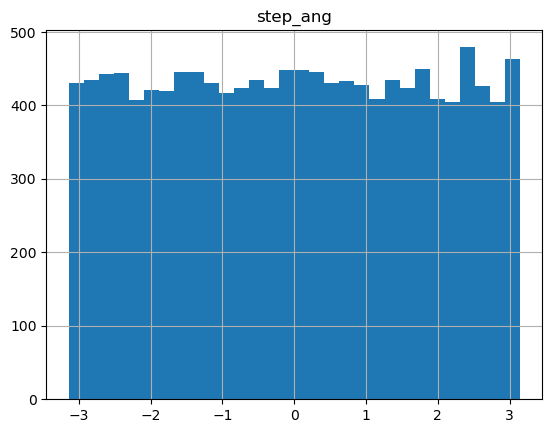

In [ ]:
df_filt = t_filt.copy()
df_filt = df_filt.groupby('particle').filter(lambda x: len(x)>10).copy()
df_filt["step_ang"] = (np.atan2(df_filt.groupby('particle')['y'].diff(1),
         df_filt.groupby('particle')['x'].diff(1) ))
df_filt.hist(column='step_ang', bins=30)

In [ ]:
# the track data from the tracker
viewer.add_tracks(
    df_filt[['particle','frame','y','x']].to_numpy(),
    properties = df_filt,
    # graph=graph,
    name="TrackPy_filt",
    blending="translucent",
    visible=True,
)

<Tracks layer 'TrackPy_filt' at 0x16056397610>

In [ ]:
# Save viewer to video

from napari_animation import Animation
# Create an animation object
animation = Animation(viewer)

# Capture keyframes programmatically
# Example: go from slice 0 to slice 49 in 100 steps
viewer.dims.set_point(0, 0) # Set first dimension to first frame
animation.capture_keyframe(steps=100) # Capture starting state

viewer.dims.set_point(0, 100) # Set first dimension to last frame
animation.capture_keyframe(steps=100) # Capture ending state

# Animate and save all frames to a video file
# The format is inferred from the file extension
output_path = r"C:\Users\victo\Downloads\divisions.mp4"
animation.animate(output_path, fps=10)

Rendering frames...


100%|██████████| 101/101 [00:06<00:00, 15.68it/s]


### DataFrame Option

In [ ]:
df = pd.concat([pd.DataFrame(track.to_dict()) for track in tracks])

In [ ]:
df['t'].max()

np.int64(49)

In [ ]:
# tracklets = [
#     Tracklet(
#         track_id=row['ID'],
#         x_coords=row['x'],
#         y_coords=row['y'],
#         frames=row['t']
#     ) 
#     for index, row in df.iterrows()
# ]

In [ ]:
df['track length_x'] = df.groupby('ID')['x'].transform(lambda x: x.iloc[-1] - x.iloc[0])
df['track length_y'] = df.groupby('ID')['y'].transform(lambda y: y.iloc[-1] - y.iloc[0])
df['track length'] = ((df['track length_x']) ** 2 + (df['track length_y']) ** 2) ** 0.5

<Axes: >

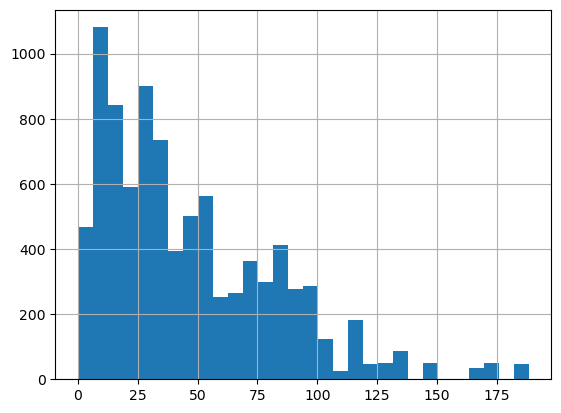

In [ ]:
df['track length'].hist(bins=30)

In [ ]:
from sklearn.neighbors import BallTree

def filter_isolated_tracks(df, min_dist, pos_cols=['x', 'y']):
    """
    Filters tracks in a DataFrame where all particles in the track have a 
    nearest neighbor distance greater than min_dist within the same time frame.
    """
    
    # Use .copy() when creating the temporary column assignment 
    # to avoid SettingWithCopyWarning if 'df' was created via slicing earlier.
    temp_df = df.copy() 
    
    temp_df['nearest_neighbor_dist'] = np.inf
    
    for t, frame_group in temp_df.groupby('t'):
        if len(frame_group) > 1:
            coords = frame_group[pos_cols].values
            tree = BallTree(coords)
            distances, indices = tree.query(coords, k=2)
            nn_distances = distances[:, 1]
            
            # Update each row directly to avoid index alignment issues
            for i, (idx, row) in enumerate(frame_group.iterrows()):
                temp_df.at[idx, 'nearest_neighbor_dist'] = nn_distances[i]

    temp_df['is_isolated_frame'] = temp_df['nearest_neighbor_dist'] > min_dist
    isolated_track_ids = temp_df.groupby('ID')['is_isolated_frame'].all()
    isolated_track_ids = isolated_track_ids[isolated_track_ids].index.tolist()
    
    filtered_df = temp_df[temp_df['ID'].isin(isolated_track_ids)].copy()
    
    # Drop the temporary columns from the result
    filtered_df = filtered_df.drop(columns=['nearest_neighbor_dist', 'is_isolated_frame'])
    
    return filtered_df




# 2. Define the minimum distance threshold
min_distance_threshold_2d = 30

# 3. Call the function
df_filtered = filter_isolated_tracks(
    df, 
    min_distance_threshold_2d 
)


In [ ]:
def add_neighbor_column(df, radius):
    # Create a copy of the dataframe to avoid modifying the original
    result_df = df.copy()
    
    # Add a new column 'has_neighbors' initialized as False
    result_df['has_neighbors'] = False
    
    # Group by frame and process each frame separately
    for frame_id, frame_data in df.groupby('t'):
        # Extract coordinates for the current frame
        coords = frame_data[['x', 'y']].values
        
        # Calculate pairwise distances
        distances = squareform(pdist(coords))
        
        # Create a mask of particles with neighbors
        # Exclude self-distances (diagonal) from neighbor calculation
        neighbor_mask = np.zeros(len(coords), dtype=bool)
        for i in range(len(coords)):
            # Check if any other particle is within radius (excluding self)
            neighbor_mask[i] = np.any(
                (distances[i, :] > 0) & (distances[i, :] <= radius)
            )
            
        # Update the 'has_neighbors' column for this frame
        result_df.loc[frame_data.index, 'has_neighbors'] = neighbor_mask
    
    # Add distance to closest point
    result_df['dist_to_closest'] = np.inf
    
    for frame_id, frame_data in result_df.groupby('ID'):
        coords = frame_data[['x', 'y']].values
        distances = squareform(pdist(coords))
        
        # Get minimum distance excluding self (diagonal)
        min_dists = np.array([np.min(distances[i, distances[i, :] > 0]) if np.any(distances[i, :] > 0) else np.inf 
                              for i in range(len(coords))])
        
        result_df.loc[frame_data.index, 'dist_to_closest'] = min_dists
    
    return result_df

df_filtered = add_neighbor_column(df_filt, 30)
# df_filtered = add_neighbor_column(df, 30)
df_filtered

NameError: name 'df' is not defined

In [ ]:
df

,ID,t,x,y,z,parent,root,state,generation,dummy,area,major_axis_length,solidity,minor_axis_length,orientation,track length_x,track length_y,track length
0,110,0,1104.987952,83.042941,0.0,110,110,5,0,False,3237.0,106.511426,0.919080,39.683156,0.635043,26.70504,9.87512,28.472393
1,110,1,1107.974668,85.728452,0.0,110,110,5,0,False,3237.0,105.255300,0.919602,39.969289,0.640134,26.70504,9.87512,28.472393
2,110,2,1109.293990,83.326208,0.0,110,110,5,0,False,3228.0,103.696517,0.905724,40.798369,0.664293,26.70504,9.87512,28.472393
3,110,3,1111.775211,86.111146,0.0,110,110,5,0,False,3203.0,99.238587,0.926526,42.122555,0.659055,26.70504,9.87512,28.472393
4,110,4,1114.061967,87.365246,0.0,110,110,5,0,False,3050.0,91.710044,0.911809,43.961628,0.701399,26.70504,9.87512,28.472393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,510,49,1177.721050,1081.306227,0.0,510,510,5,0,False,1943.0,53.744358,0.962834,47.135178,-1.464812,0.00000,0.00000,0.000000
0,511,49,490.060851,1079.140000,0.0,50,50,5,1,False,2350.0,72.474722,0.943018,43.112896,1.365160,0.00000,0.00000,0.000000
0,513,49,424.014955,116.730808,0.0,513,513,5,0,False,1003.0,42.481149,0.963497,30.501091,0.590353,0.00000,0.00000,0.000000
0,514,49,6.090909,149.000000,0.0,514,514,5,0,False,66.0,11.022573,0.804878,8.588632,-0.334126,0.00000,0.00000,0.000000


In [ ]:
df_filtered = df[df['track length'] > 50]  # Example threshold

In [ ]:
viewer = napari.Viewer()

image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[:, :] for im in image_list]) 

viewer.add_image(
    # segmentation,
    raws,
    name="Segmentation",
    opacity=0.2,
)

# the track data from the tracker
viewer.add_tracks(
    df_filtered[['ID','t','y','x']].to_numpy(),
    properties = df_filtered,
    # graph=graph,
    name="Tracks",
    blending="translucent",
    visible=True,
)

<Tracks layer 'Tracks' at 0x2c473215720>

In [ ]:
# TODO:
# select only long moving tracks (track_length = df['x'].iloc[-1]-df['x'].iloc[0])
# visualize defect pairs with napari (annihilations and creations)

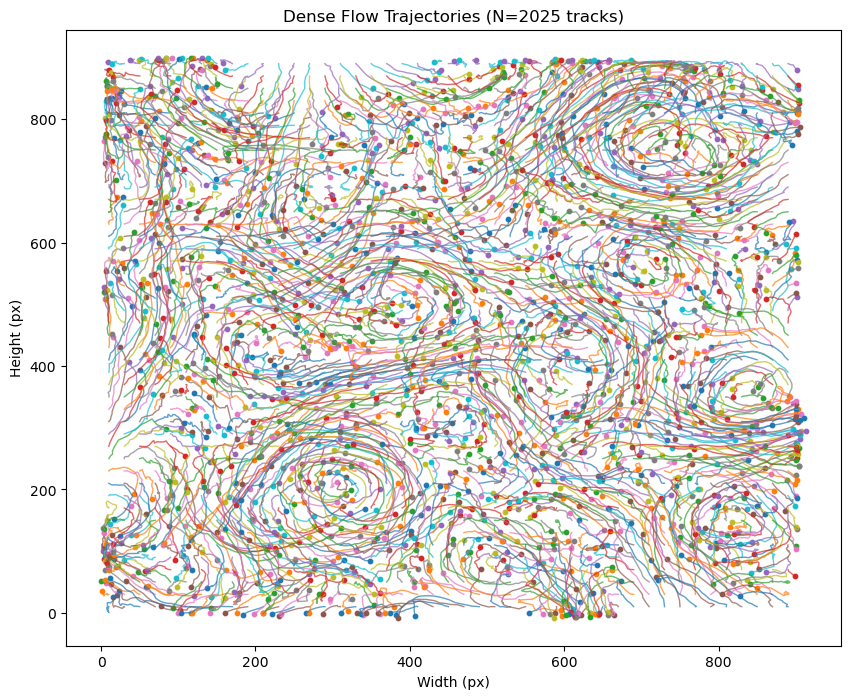

In [ ]:
import numpy as np
from scipy.interpolate import interpn

def flow_to_tracks(flow_series, step=40, iterations=None):
    """
    Converts a sequence of dense flow fields into trajectories.
    
    :param flow_series: List or array of shape (T, H, W, 2) where [..., 0] is dx and [..., 1] is dy
    :param step: N (integer). Seeds a track every N pixels.
    :param iterations: Number of frames to process.
    :return: Array of tracks with shape (Num_Tracks, T, 2)
    """
    T, H, W, _ = flow_series.shape
    iterations = iterations if iterations else T
    
    # 1. Initialize Seed Points (x, y) every N pixels
    yy, xx = np.mgrid[step//2:H:step, step//2:W:step]
    # ensure floating point positions to allow in-place addition of float displacements
    current_points = np.vstack([xx.ravel(), yy.ravel()]).T.astype(np.float64)
    
    # Initialize track storage: (Number of points, Time, 2) as float
    tracks = np.zeros((current_points.shape[0], iterations + 1, 2), dtype=np.float64)
    tracks[:, 0, :] = current_points
    
    # Define grid coordinates for interpolation
    grid_y = np.arange(H)
    grid_x = np.arange(W)

    # 2. Integrate Velocity Vectors
    for t in range(iterations):
        # Extract flow for the current frame
        flow_frame = flow_series[t]
        
        # Interpolate dx and dy at the current floating-point positions
        # Using 'linear' to handle points between pixels
        dx = interpn((grid_y, grid_x), flow_frame[..., 0], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        dy = interpn((grid_y, grid_x), flow_frame[..., 1], 
                     current_points[:, [1, 0]], method='linear', bounds_error=False, fill_value=0.0)
        
        # 3. Update Positions: x_new = x + dx, y_new = y + dy
        current_points[:, 0] += dx
        current_points[:, 1] += dy
        
        # Store the updated position
        tracks[:, t + 1, :] = current_points

    return tracks

def visualize_tracks(tracks, shape, background=None):
    """
    Plots trajectories over an image or blank background.
    """
    H, W = shape
    plt.figure(figsize=(10, 8))

    
    # Plot each track
    for i in range(len(tracks)):
        # x is index 1, y is index 0
        plt.plot(tracks[i, :, 1], tracks[i, :, 0], linewidth=1, alpha=0.7)
        
        # Draw a small dot at the 'head' of the track
        plt.scatter(tracks[i, -1, 1], tracks[i, -1, 0], s=10)

    plt.title(f"Dense Flow Trajectories (N={len(tracks)} tracks)")
    plt.xlabel("Width (px)")
    plt.ylabel("Height (px)")
    plt.show()

# --- Example Usage ---
# Create dummy flow: Constant movement of 1 pixel right and 1 pixel down
# Shape: (10 frames, 100 height, 100 width, 2 channels)
# dummy_flow = np.ones((10, 100, 100, 2)) 

# trajectories = flow_to_tracks(dummy_flow, step=20)
# print(f"Generated {trajectories.shape[0]} tracks over {trajectories.shape[1]} timestamps.")


# --- Simulation for Demo ---
# 1. Create a dummy flow (rotating vortex)
T, H, W = 20, 200, 200
flow_data = np.zeros((T, H, W, 2))
y, x = np.mgrid[0:H, 0:W]
for t in range(T):
    # Create a simple rotation effect
    flow_data[t, ..., 0] = -(y - H/2) * 0.1  # dx
    flow_data[t, ..., 1] = (x - W/2) * 0.1   # dy

# 2. Convert to tracks
# trajectories = flow_to_tracks(flow_data, step=50)
trajectories = flow_to_tracks(np.array(flows), step=20)
# 3. Visualize
visualize_tracks(trajectories, (H, W))


In [ ]:
n_tracks, n_timesteps, _ = trajectories.shape
track_ids = np.repeat(np.arange(n_tracks), n_timesteps)
times = np.tile(np.arange(n_timesteps), n_tracks)
coords = trajectories.reshape(n_tracks * n_timesteps, 2)

df_trajectories = pd.DataFrame({
    'track_id': track_ids,
    't': times,
    'x': coords[:, 0],
    'y': coords[:, 1],
})

viewer = napari.Viewer()
viewer.add_tracks(
    df_trajectories[['track_id', 't', 'y', 'x']].to_numpy(),
    properties=df_trajectories,
    name='DenseTracks',
    blending='translucent',
    visible=True,
)

df_trajectories.head()

df_trajectories.head()



,track_id,t,x,y
0,0,0,10.000000,10.000000
1,0,1,5.749600,9.002967
2,0,2,3.942258,8.969983
3,0,3,0.812807,9.886971
4,0,4,0.402549,10.071306


In [ ]:
viewer.add_tracks(
    df_trajectories[['track_id', 't', 'y', 'x']].to_numpy(),
    properties=df_trajectories,
    name='DenseTracks',
    blending='translucent',
    visible=True,
)

<Tracks layer 'DenseTracks' at 0x1e2cd3efa30>

In [ ]:
%matplotlib qt
for track_id, group in df_trajectories.groupby('track_id'):
    plt.plot(group['x'], group['y'], linewidth=1, alpha=0.7)


In [ ]:
df_trajectories

array([[[ 1.00000000e+01,  1.00000000e+01],
        [ 7.83635402e+00,  1.16669420e+01],
        [ 6.07198156e+00,  1.48812118e+01],
        ...,
        [-1.83338772e+00,  1.75891275e+01],
        [-1.83338772e+00,  1.75891275e+01],
        [-1.83338772e+00,  1.75891275e+01]],

       [[ 3.00000000e+01,  1.00000000e+01],
        [ 2.69903905e+01,  1.19465411e+01],
        [ 2.11305133e+01,  1.29640083e+01],
        ...,
        [-1.53155836e-01,  1.21855688e+01],
        [-1.53155836e-01,  1.21855688e+01],
        [-1.53155836e-01,  1.21855688e+01]],

       [[ 5.00000000e+01,  1.00000000e+01],
        [ 4.45994005e+01,  9.31935459e+00],
        [ 3.84930832e+01,  1.01518169e+01],
        ...,
        [-2.29008265e-01,  1.00873346e+01],
        [-2.29008265e-01,  1.00873346e+01],
        [-2.29008265e-01,  1.00873346e+01]],

       ...,

       [[ 8.50000000e+02,  8.90000000e+02],
        [ 8.46728432e+02,  8.88500199e+02],
        [ 8.43069627e+02,  8.85193290e+02],
        ...,
     